## Explicação do dataset criado

## Parâmentros de variáveis

In [3]:
# !pip install truncnorm

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import truncnorm

# ========================
# PARÂMETROS DO DATASET
# ========================

PARAMS = {
    "n_alunos": 100000,
    # "proporcao_evasao_geral": 0.10,   # calculada como média entre as evasões por etapa
    "evasao_por_etapa": {
        "1° EF": 0.02, "2° EF": 0.02, "3° EF": 0.03, "4° EF": 0.03,
        "5° EF": 0.04, "6° EF": 0.08, "7° EF": 0.10, "8° EF": 0.12,
        "9° EF": 0.15, "1° EM": 0.18, "2° EM": 0.16, "3° EM": 0.14
    },
    "p_estudante_nis": 0.3,
    "p_estudante_nis_evadiu": 0.45,
    "p_informou_nome_mae": 0.95,
    "p_informou_nome_mae_evadiu": 0.9,
    "p_informou_nome_pai": 0.7,
    "p_informou_nome_pai_evadiu": 0.6,
    "p_possui_deficiencia": 0.05,
    "p_possui_deficiencia_evadiu": 0.08,
    "p_repetente": 0.047,
    "p_repetente_evadiu": 0.2,
    "p_trabalha": 0.15,
    "p_trabalha_evadiu": 0.25,
    "p_problemas_de_saude": 0.1,
    "p_problemas_de_saude_evadiu": 0.15,
    "p_gravidez_na_adolescencia": 0.03,
    "p_gravidez_na_adolescencia_evadiu": 0.08,
    "p_necessita_assistencia_social": 0.3,
    "p_necessita_assistencia_social_evadiu": 0.45,
    "raca_cor_p": [0.35, 0.1, 0.45, 0.05, 0.02, 0.03],
    "tipo_localizacao_p": [0.8, 0.2], 
    "situacao_consolidada_p": [0.7, 0.15, 0.1, 0.05],
    "infraestrutura_p": [0.5, 0.3, 0.2],
    "random_seed": 42
}

infraestrutura_vals = ['Boa', 'Regular', 'Ruim']

MAPA_ETAPA_IDADE = {
    "1° EF": 6, "2° EF": 7, "3° EF": 8, "4° EF": 9, "5° EF": 10,
    "6° EF": 11, "7° EF": 12, "8° EF": 13, "9° EF": 14,
    "1° EM": 15, "2° EM": 16, "3° EM": 17
}

random.seed(PARAMS["random_seed"])
np.random.seed(PARAMS["random_seed"])

# ========================
# LISTAS DE CATEGORIAS
# ========================

etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF",
          "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

sexos = ['Masculino', 'Feminino', 'Outro']
raca_list = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada']

# ========================
# FUNÇÕES AUXILIARES
# ========================

def gerar_etapas(n):
    qtd_matriculas_etapas = np.array([28087, 29163, 33253, 28054, 28682, 29944,
                                      30364, 28886, 30368, 31195, 29372, 25056], dtype=float)
    distr = qtd_matriculas_etapas / qtd_matriculas_etapas.sum()
    return list(np.random.choice(etapas, size=n, p=distr))

def gerar_evasao_por_etapa(etapa):
    prop_evasao_da_etapa = PARAMS["evasao_por_etapa"].get(etapa, np.mean(list(PARAMS["evasao_por_etapa"].values())))
    return random.choices([True, False], weights=[prop_evasao_da_etapa, 1 - prop_evasao_da_etapa])[0]

# ========================
# GERAÇÃO DE VARIÁVEIS
# ========================

idades = list(range(6, 20))
pesos_idades = np.linspace(1, 0.5, len(idades))  
pesos_idades_evadiu = np.linspace(0.3, 1, len(idades))  

def gerar_idade(evadiu: bool):
    return random.choices(idades, weights=pesos_idades_evadiu if evadiu else pesos_idades)[0]

def gerar_sexo(evadiu: bool):
    return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]

def gerar_estudante_nis(evadiu: bool):
    p = PARAMS["p_estudante_nis_evadiu"] if evadiu else PARAMS["p_estudante_nis"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_informou_nome_mae(evadiu: bool):
    p = PARAMS["p_informou_nome_mae_evadiu"] if evadiu else PARAMS["p_informou_nome_mae"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_informou_nome_pai(evadiu: bool):
    p = PARAMS["p_informou_nome_pai_evadiu"] if evadiu else PARAMS["p_informou_nome_pai"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_possui_deficiencia(evadiu: bool):
    p = PARAMS["p_possui_deficiencia_evadiu"] if evadiu else PARAMS["p_possui_deficiencia"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_repetente(evadiu: bool):
    p = PARAMS["p_repetente_evadiu"] if evadiu else PARAMS["p_repetente"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_trabalha(evadiu: bool):
    p = PARAMS["p_trabalha_evadiu"] if evadiu else PARAMS["p_trabalha"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_problemas_de_saude(evadiu: bool):
    p = PARAMS["p_problemas_de_saude_evadiu"] if evadiu else PARAMS["p_problemas_de_saude"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_gravidez_na_adolescencia(evadiu: bool):
    p = PARAMS["p_gravidez_na_adolescencia_evadiu"] if evadiu else PARAMS["p_gravidez_na_adolescencia"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_necessita_assistencia_social(evadiu: bool):
    p = PARAMS["p_necessita_assistencia_social_evadiu"] if evadiu else PARAMS["p_necessita_assistencia_social"]
    return random.choices([True, False], weights=[p, 1 - p])[0]

def gerar_infraestrutura(evadiu: bool):
    pesos_evadiu = [0.35, 0.4, 0.25]
    return random.choices(infraestrutura_vals, weights=pesos_evadiu if evadiu else PARAMS["infraestrutura_p"])[0]

def gerar_distancia(evadiu: bool):
    media = 3 if evadiu else 2 
    return round(abs(np.random.normal(media, 1)), 1)

def gerar_renda(evadiu: bool):
    salario_min = 1139.4 
    faixas = [(0.0, 0.5), (0.5, 1.0), (1.0, 1.5), (1.5, 3.0), (3.0, 5.0), (5.0, 10.0)]
    if evadiu:
        pesos = [0.25, 0.35, 0.25, 0.12, 0.02, 0.01]
    else:
        pesos = [0.05, 0.15, 0.30, 0.35, 0.12, 0.03]
    faixa_escolhida = random.choices(faixas, weights=pesos)[0]
    renda_sm = random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    return round(renda_sm * salario_min, 2)

def gerar_nivel_socioeconomico(evadiu: bool):
    niveis = ["Muito baixo", "Baixo", "Médio", "Alto", "Muito alto"]
    pesos_evadiu = [0.3, 0.4, 0.25, 0.04, 0.01]
    return random.choices(niveis, weights=pesos_evadiu if evadiu else [0.1, 0.3, 0.4, 0.15, 0.05])[0]

def gerar_raca(evadiu: bool):
    pesos_evadiu = [0.25, 0.15, 0.45, 0.03, 0.02, 0.1]
    return random.choices(raca_list, weights=pesos_evadiu if evadiu else PARAMS["raca_cor_p"])[0]

def gerar_tipo_localizacao(evadiu: bool):
    return random.choices(['Urbana', 'Rural'], weights=[0.7, 0.3] if evadiu else PARAMS["tipo_localizacao_p"])[0]

def gerar_situacao_consolidada(evadiu: bool):
    if evadiu: return 'Evadido'
    return random.choices(['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'], weights=PARAMS["situacao_consolidada_p"])[0]

def gerar_nota(evadiu: bool):
    dist = {(0, 5): 0.45, (5, 7): 0.40, (7, 10): 0.15} if evadiu else {(0, 5): 0.2, (5, 7): 0.35, (7, 10): 0.45}
    faixa = random.choices(list(dist.keys()), weights=list(dist.values()))[0]
    return round(np.random.uniform(*faixa), 1)

def gerar_frequencia(evadiu: bool):
    media = 75 if evadiu else 90
    desvio = 10
    a, b = (0 - media) / desvio, (100 - media) / desvio
    return round(truncnorm.rvs(a, b, loc=media, scale=desvio), 1)

# ========================
# GERAÇÃO DO DATASET
# ========================

n_alunos = PARAMS["n_alunos"]
etapa_series = gerar_etapas(n_alunos) 
serie_evasao = [random.random() < gerar_evasao_por_etapa(etapa) for etapa in etapa_series]

# cria DataFrame inicial
df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'etapa_ensino': etapa_series,
    'evasao': serie_evasao,
})

print("Gerando colunas base...")
df['idade'] = [gerar_idade(e) for e in df['evasao']]
df['sexo'] = [gerar_sexo(e) for e in df['evasao']]
df['estudante_nis'] = [gerar_estudante_nis(e) for e in df['evasao']]
df['informou_nome_mae'] = [gerar_informou_nome_mae(e) for e in df['evasao']]
df['informou_nome_pai'] = [gerar_informou_nome_pai(e) for e in df['evasao']]
df['possui_deficiencia'] = [gerar_possui_deficiencia(e) for e in df['evasao']]
df['raca_cor'] = [gerar_raca(e) for e in df['evasao']]
df['tipo_localizacao_endereco_estudante'] = [gerar_tipo_localizacao(e) for e in df['evasao']]
df['situacao_consolidada_no_ano'] = [gerar_situacao_consolidada(e) for e in df['evasao']]
df['repetente'] = [gerar_repetente(e) for e in df['evasao']]
df['frequencia_escolar'] = [gerar_frequencia(e) for e in df['evasao']]
df['notas_medias'] = [gerar_nota(e) for e in df['evasao']]
df['nivel_socioeconomico'] = [gerar_nivel_socioeconomico(e) for e in df['evasao']]
df['renda_familiar'] = [gerar_renda(e) for e in df['evasao']]
df['distancia_da_escola_km'] = [gerar_distancia(e) for e in df['evasao']]
df['trabalha'] = [gerar_trabalha(e) for e in df['evasao']]
df['problemas_de_saude'] = [gerar_problemas_de_saude(e) for e in df['evasao']]
df['gravidez_na_adolescencia'] = [gerar_gravidez_na_adolescencia(e) for e in df['evasao']]
df['necessita_assistencia_social'] = [gerar_necessita_assistencia_social(e) for e in df['evasao']]
df['infraestrutura_escolar'] = [gerar_infraestrutura(e) for e in df['evasao']]
df['evasao_confirmada'] = df['evasao']
df['idade_esperada'] = df['etapa_ensino'].map(MAPA_ETAPA_IDADE)
df['idade_esperada'] = df['idade_esperada'].fillna(df['idade'])
df['anos_de_atraso'] = df['idade'] - df['idade_esperada']
df['reprovacao_por_falta'] = (df['frequencia_escolar'] < 75).astype(int)
df['nota_vermelha'] = (df['notas_medias'] < 5.0).astype(int)
df['perfil_desengajado'] = ((df['notas_medias'] > 7) & (df['frequencia_escolar'] < 80)).astype(int)

Gerando colunas base...


## Análise Exploratória

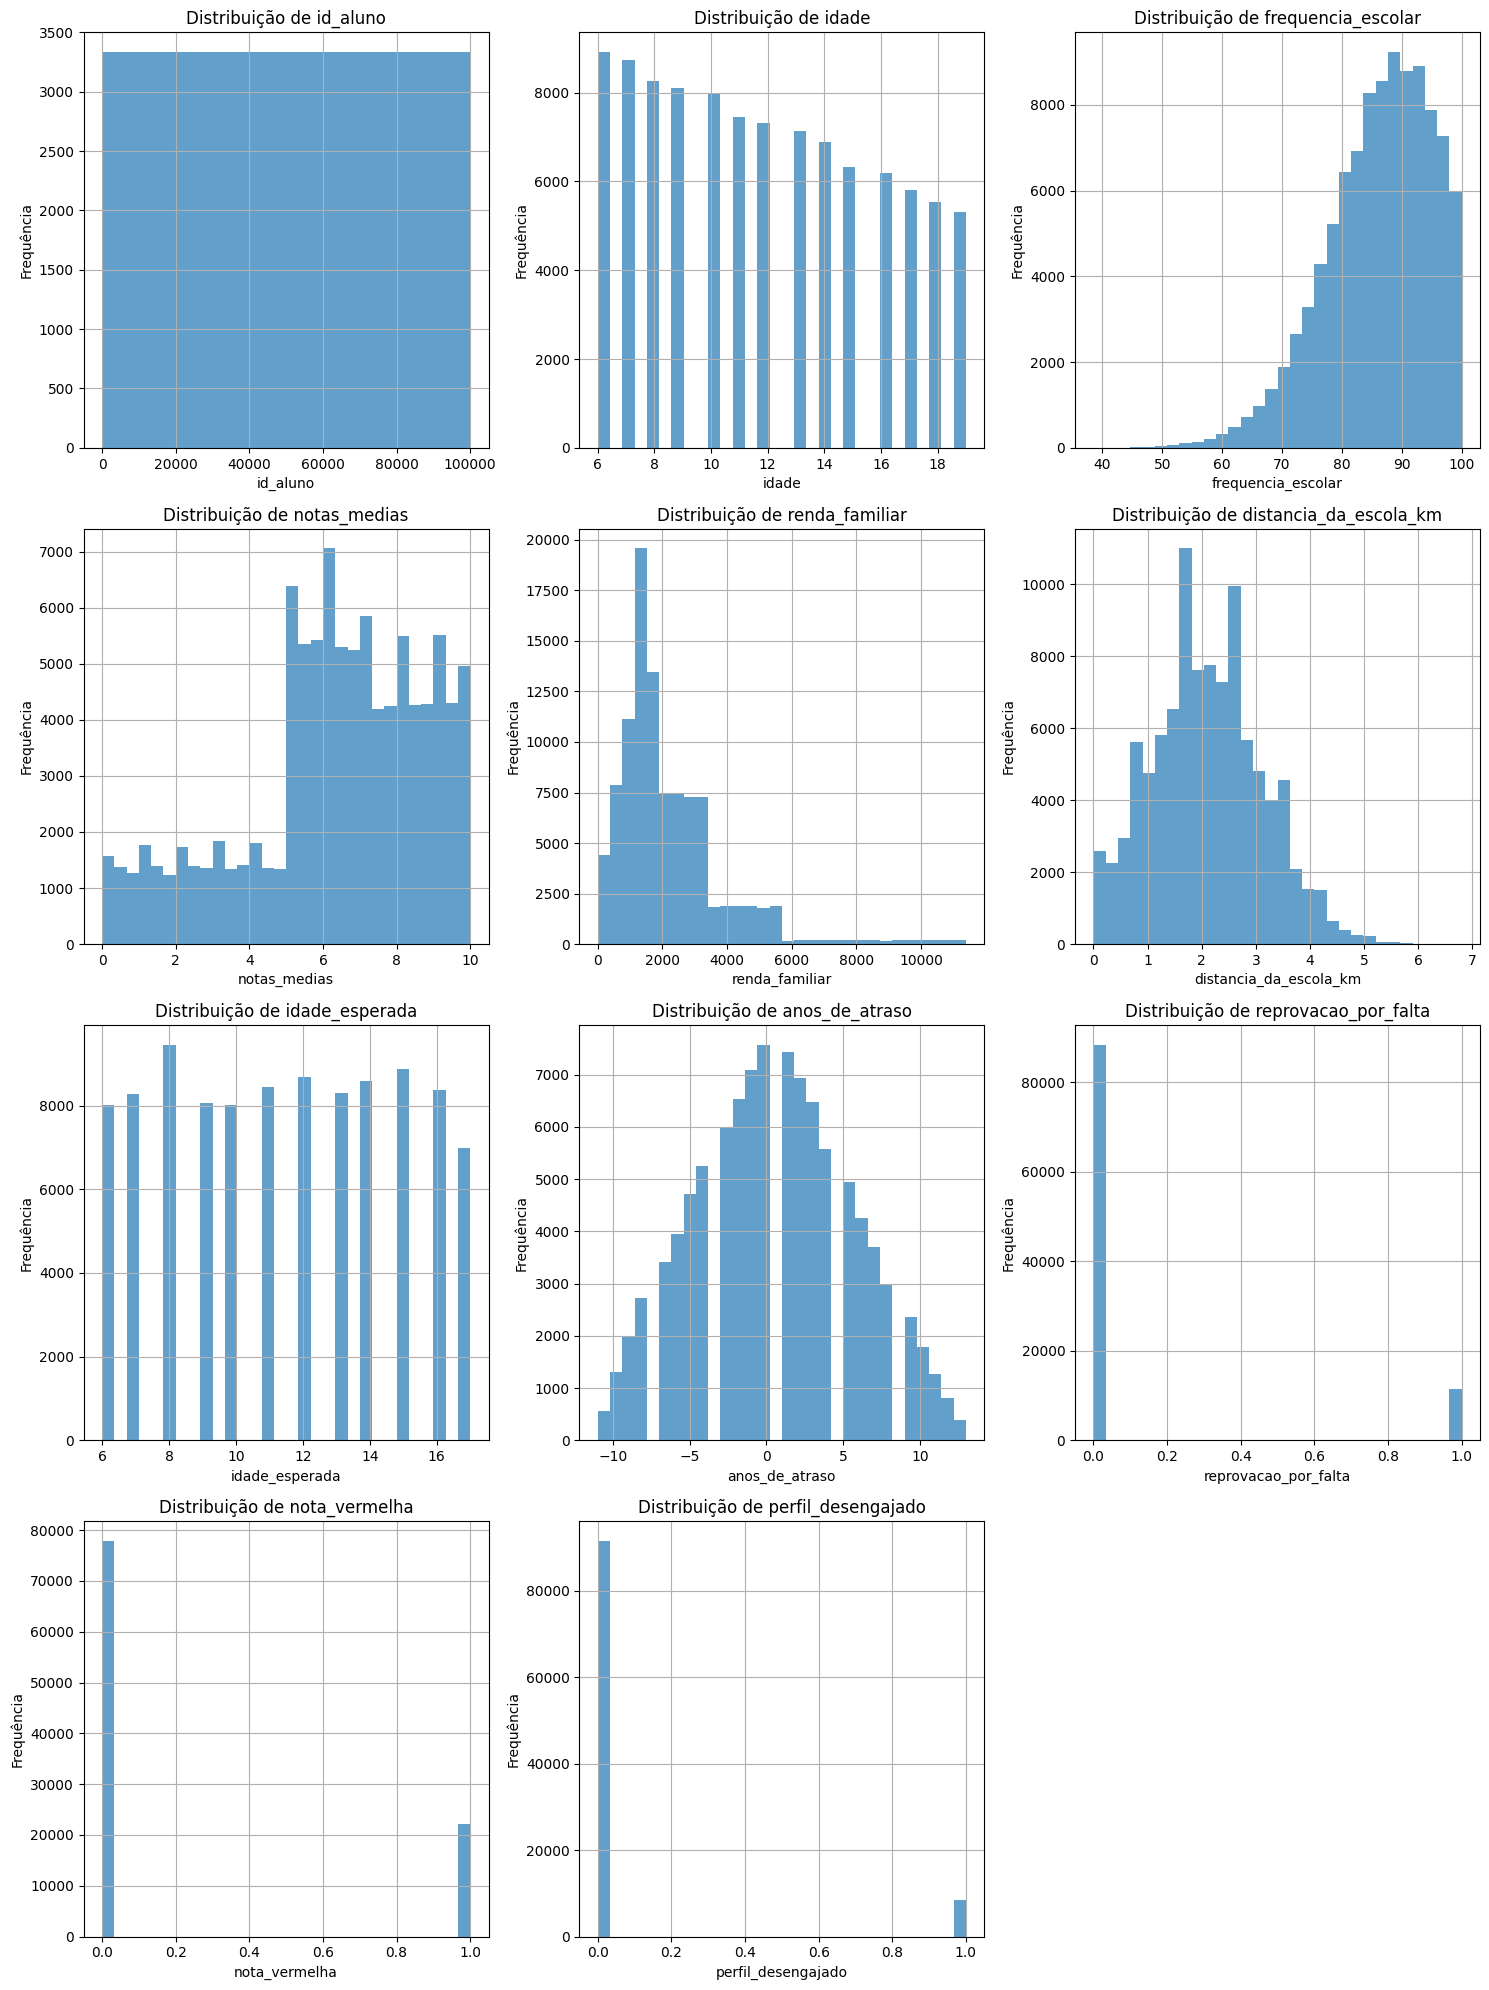

========== Var. Categóricas ==========


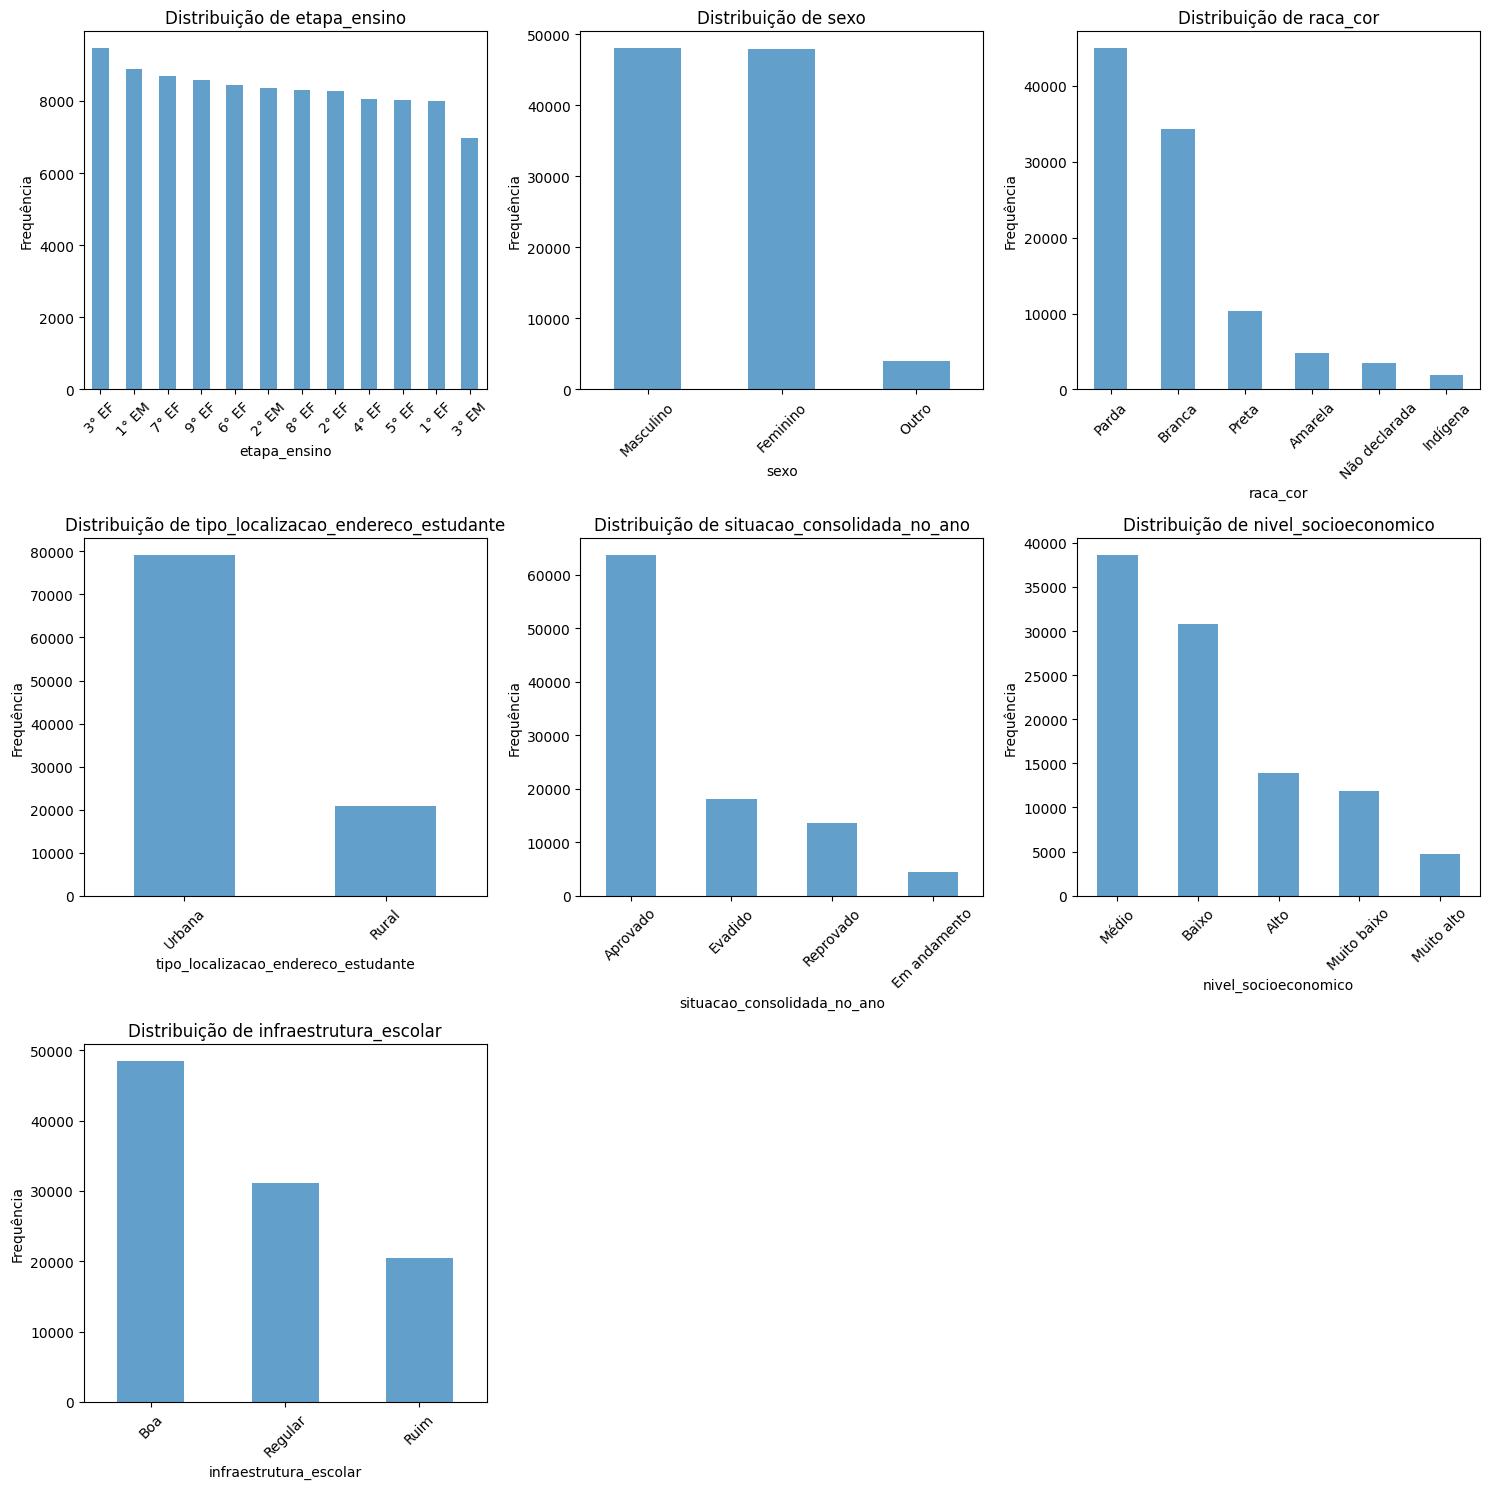


Total de alunos: 100000
Total de evasões geradas: 8887 (8.89%)


In [5]:
def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
print("="*10 + " Var. Categóricas " + "="*10)
plot_categorical_distributions(df)

# Print da quantidade de evasões geradas e não evasões
total_evasoes = df['evasao'].astype(int).sum()
print(f"\nTotal de alunos: {n_alunos}")
print(f"Total de evasões geradas: {total_evasoes} ({(total_evasoes / n_alunos) * 100:.2f}%)")

## Heat Map

In [6]:
# !pip install seaborn

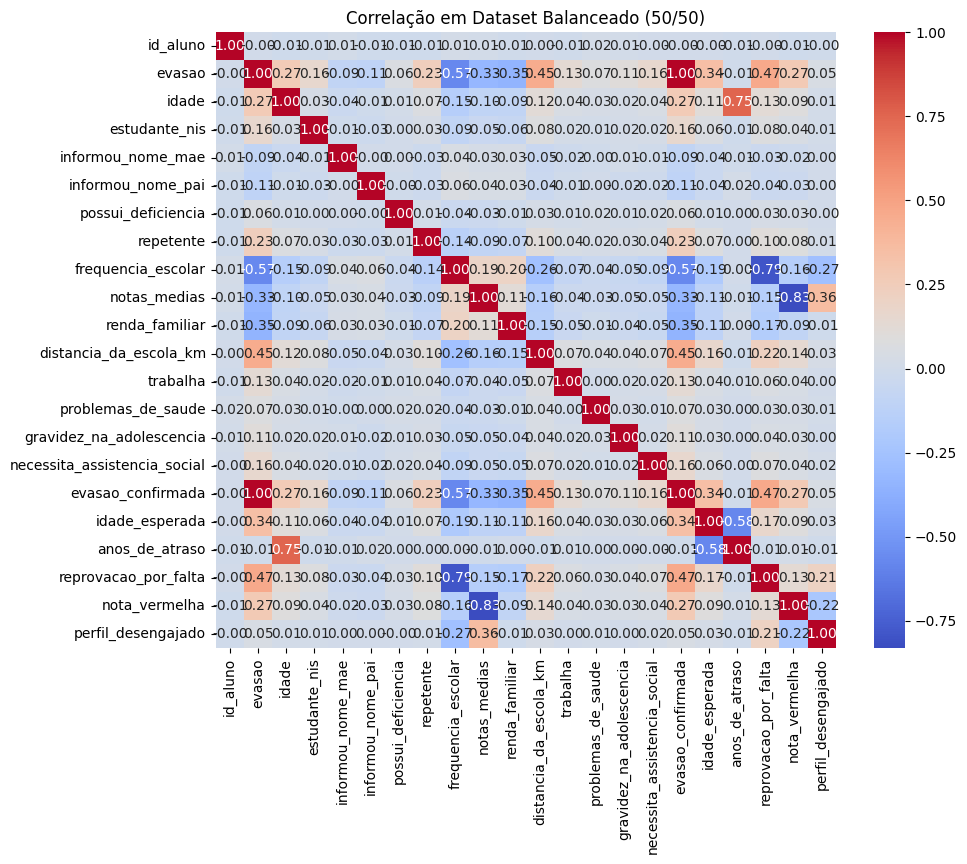

In [7]:
# --- TÉCNICA DE VALIDAÇÃO ---

df_evadidos = df[df['evasao'] == 1]
df_nao_evadidos = df[df['evasao'] == 0]

df_nao_evadidos_sample = df_nao_evadidos.sample(n=len(df_evadidos), random_state=42)

df_visualizacao = pd.concat([df_evadidos, df_nao_evadidos_sample])

import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(df_visualizacao.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlação em Dataset Balanceado (50/50)")
plt.show()

## Random Forest

In [8]:
# treinar modelo randomforest para prever evasao
print("Preparando dados para o modelo...")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

# Preparar features e target
X = df.drop(['id_aluno', 'evasao', 'evasao_confirmada', 'situacao_consolidada_no_ano', 'idade_esperada'], axis=1)

# Encoding de variáveis categóricas
label_encoders = {}
categorical_cols = ['etapa_ensino', 'sexo', 'raca_cor', 'tipo_localizacao_endereco_estudante', 
                    'nivel_socioeconomico', 'infraestrutura_escolar']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# Converter booleanos para int
bool_cols = X.select_dtypes(include=['bool']).columns
X[bool_cols] = X[bool_cols].astype(int)

y = df['evasao']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=PARAMS["random_seed"], stratify=y)

print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")

Preparando dados para o modelo...
Tamanho do conjunto de treino: 80000
Tamanho do conjunto de teste: 20000


In [9]:
# Otimização de hiperparâmetros 
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("""Parâmetros para otimização:
- n_estimators: número de árvores na floresta
- max_depth: profundidade máxima de cada árvore
- min_samples_split: número mínimo de amostras necessárias para dividir um nó
- min_samples_leaf: número mínimo de amostras necessárias em um nó folha
""")

print("\nOtimizando hiperparâmetros do Random Forest...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=PARAMS["random_seed"]),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
rf_model = grid_search.best_estimator_

Parâmetros para otimização:
- n_estimators: número de árvores na floresta
- max_depth: profundidade máxima de cada árvore
- min_samples_split: número mínimo de amostras necessárias para dividir um nó
- min_samples_leaf: número mínimo de amostras necessárias em um nó folha


Otimizando hiperparâmetros do Random Forest...
Melhores parâmetros encontrados: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [10]:
# Treinar Random Forest
print("\nTreinando Random Forest...")
#rf_model = RandomForestClassifier(n_estimators=100, random_state=PARAMS["random_seed"], max_depth=10, min_samples_split=5)
rf_model.fit(X_train, y_train)


Treinando Random Forest...


,n_estimators,100
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
# Obtenha as probabilidades de evasão
y_proba = rf_model.predict_proba(X_test)[:, 1]
# Defina um threshold menor,
threshold = 0.05
y_pred = (y_proba >= threshold).astype(int)

# Avaliação
print("\n" + "="*50)
print("RESULTADOS DO MODELO")
print("="*50)
print(f"\nAcurácia: {accuracy_score(y_test, y_pred):.4f}")

print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")

print("\nMatriz de Confusão:")
# Matriz de confusão formatada, com headers
cm = confusion_matrix(y_test, y_pred)
print("      Previsto Não Evadiu | Previsto Evadiu")
print(f"Real Não Evadiu    {cm[0,0]:>8}           {cm[0,1]:>8}")
print(f"Real Evadiu        {cm[1,0]:>8}           {cm[1,1]:>8}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))



RESULTADOS DO MODELO

Acurácia: 0.7631
Precisão: 0.2677
Recall: 0.9600

Matriz de Confusão:
      Previsto Não Evadiu | Previsto Evadiu
Real Não Evadiu       13557               4666
Real Evadiu              71               1706

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.99      0.74      0.85     18223
        True       0.27      0.96      0.42      1777

    accuracy                           0.76     20000
   macro avg       0.63      0.85      0.63     20000
weighted avg       0.93      0.76      0.81     20000



In [12]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features mais importantes:")
print(feature_importance.head(10))


Top 10 Features mais importantes:
                   feature  importance
10      frequencia_escolar    0.202098
13          renda_familiar    0.146186
14  distancia_da_escola_km    0.132730
21    reprovacao_por_falta    0.078571
11            notas_medias    0.074323
1                    idade    0.056476
20          anos_de_atraso    0.047977
0             etapa_ensino    0.038003
9                repetente    0.030642
12    nivel_socioeconomico    0.029705


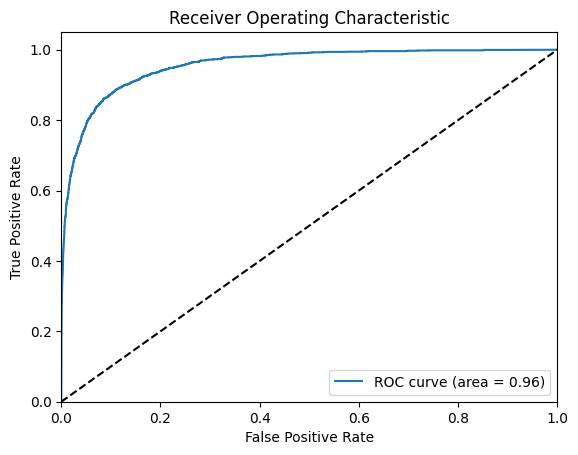

In [13]:
# Apresentar AUC e ROC
from sklearn.metrics import roc_auc_score, roc_curve
auc = roc_auc_score(y_test, y_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show() 

## Exportando

In [14]:
csv_path = "./dataset_evasao_sintetico_v7.csv"
df.to_csv(csv_path, index=False)

print("-" * 30)
print(f"Dataset salvo em: {csv_path}")
print(f"Taxa de Evasão: {df['evasao_confirmada'].mean():.2%}")
print("-" * 30)
print("Amostra das novas colunas:")
cols_novas = ['etapa_ensino', 'idade', 'idade_esperada', 'anos_de_atraso', 'nota_vermelha', 'perfil_desengajado']
print(df[cols_novas].head(10))

------------------------------
Dataset salvo em: ./dataset_evasao_sintetico_v7.csv
Taxa de Evasão: 8.89%
------------------------------
Amostra das novas colunas:
  etapa_ensino  idade  idade_esperada  anos_de_atraso  nota_vermelha  \
0        5° EF     19              10               9              0   
1        3° EM      7              17             -10              0   
2        9° EF     10              14              -4              0   
3        8° EF     16              13               3              0   
4        2° EF      7               7               0              0   
5        2° EF     14               7               7              0   
6        1° EF     11               6               5              0   
7        2° EM     19              16               3              1   
8        8° EF      9              13              -4              0   
9        9° EF     15              14               1              1   

   perfil_desengajado  
0                   